In [1]:
# 导入函数库
import os

os.chdir('/home/xizhang/MRCDFT/MR_CDFT_f90/dataprocessing')
from functionboxes import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.axes as mpl_axes
from scipy.interpolate import interp1d
from typing import List, Tuple, Optional, Any, Dict
# import sys
# import os
# sys.path.insert(0, os.path.join(os.path.dirname(__file__), 'functionboxes'))
# from functionboxes import *
from topJournalPalettes import TopJournalPalettes as tjp


In [2]:
from functionboxes import *
from functionboxes.topJournalPalettes import TopJournalPalettes as tjp
# 导入函数库
import os
import sys
import io
# 设置标准输出编码为 UTF-8，解决输出面板中文乱码问题
# if sys.stdout.encoding != 'utf-8':
#     sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
# if sys.stderr.encoding != 'utf-8':
#     sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8')

# os.chdir('/home/xizhang/MRCDFT/MR_CDFT_f90/dataprocessing')
from functionboxes import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.axes as mpl_axes
from matplotlib.font_manager import FontProperties
from scipy.interpolate import interp1d
from typing import List, Tuple, Optional, Any, Dict
import pickle
import warnings


def interpolated_data(df_origin, y_columns,num_points=1000, kind='cubic'):


    # 获取数据
    df = df_origin.copy()
    x = df['beta2'].values.astype(float)

    # 创建统一的插值网格
    x_uniform = np.linspace(x.min(), x.max(), num_points)

    # 存储插值结果
    interpolated_data_dict = {'beta2': x_uniform}

    # 处理每个列
    for col in y_columns:
        y_data = df[col].values.astype(float)
        
        # 创建非NaN掩码
        mask = ~np.isnan(y_data)
        
        # 找到连续非NaN段的边界
        diff = np.diff(mask.astype(int))
        split_indices = np.where(diff != 0)[0] + 1
        
        # 初始化插值结果数组
        y_interp = np.full(num_points, np.nan)
        
        # 处理每个分段
        start_indices = [0] + split_indices.tolist()
        end_indices = split_indices.tolist() + [len(y_data)]
        
        for s, e in zip(start_indices, end_indices):
            if s >= e:
                continue
                
            seg_x = x[s:e]
            seg_y = y_data[s:e]
            if np.all(np.isnan(seg_y)):
                continue
            
            # 单点段直接赋值
            if len(seg_x) == 1:
                idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                y_interp[idx] = seg_y[0]
                continue
                
            # 创建插值函数
            f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
            
            # 在当前分段范围内插值
            segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
            y_interp[segment_mask] = f(x_uniform[segment_mask])
        
        # 存储插值结果
        interpolated_data_dict[col] = y_interp
    return pd.DataFrame(interpolated_data_dict)


class StyleConfig:
    """
    样式配置类，从 matplotlib rcParams 读取默认值并管理全局样式。
    
    参数优先级（从高到低）：
    1. 显式传入的 override 值
    2. custom_defaults 自定义默认值
    3. matplotlib rcParams
    """
    
    # rcParams 键映射表
    RC_PARAMS_MAP = {
        'fontsize_subtitle': 'axes.titlesize',
        'fontsize_ylabel': 'axes.labelsize',
        'fontsize_xlabel': 'axes.labelsize',
        'fontsize_legend': 'legend.fontsize',
        'linewidth_default': 'lines.linewidth',
        'dpi_default': 'figure.dpi',
    }
    
    # 字体大小字符串到数值的映射
    FONTSIZE_STRING_MAP = {
        'xx-small': 6, 'x-small': 8, 'small': 10,
        'medium': 12, 'large': 14, 'x-large': 16,
        'xx-large': 18, 'larger': 16, 'smaller': 10,
    }
    
    def __init__(self, custom_defaults: Optional[Dict[str, Any]] = None):
        """
        初始化样式配置。
        
        Args:
            custom_defaults: 自定义默认值字典，会覆盖 rcParams 的值
        """
        self.custom_defaults = custom_defaults or {}
        
    def _get_rc_param(self, param_name: str) -> Any:
        """从 rcParams 获取参数值。"""
        rc_key = self.RC_PARAMS_MAP.get(param_name)
        if rc_key:
            return plt.rcParams.get(rc_key)
        return None
    
    def _convert_fontsize(self, size) -> float:
        """
        将字体大小转换为数值。
        rcParams 中的字体大小可能是字符串（如 'medium', 'large'）。
        """
        if size is None:
            return 12.0  # 默认值
        
        if isinstance(size, (int, float)):
            return float(size)
        
        # 字符串映射
        size_str = str(size).lower()
        if size_str in self.FONTSIZE_STRING_MAP:
            return float(self.FONTSIZE_STRING_MAP[size_str])
        
        # 尝试直接转换为浮点数
        try:
            return float(size)
        except (ValueError, TypeError):
            return 12.0  # 默认值
    
    def get_value(self, param_name: str, override: Any = None, convert_fontsize: bool = False) -> Any:
        """
        获取参数值，支持显式覆盖。
        
        优先级：override > custom_defaults > rcParams
        
        Args:
            param_name: 参数名称（如 'fontsize_subtitle'）
            override: 显式覆盖值（最高优先级）
            convert_fontsize: 是否将字符串字体大小转换为数值
            
        Returns:
            解析后的参数值
        """
        # 最高优先级：显式覆盖
        if override is not None:
            if convert_fontsize:
                return self._convert_fontsize(override)
            return override
        
        # 第二优先级：自定义默认值
        if param_name in self.custom_defaults:
            value = self.custom_defaults[param_name]
            if convert_fontsize:
                return self._convert_fontsize(value)
            return value
        
        # 最低优先级：rcParams
        rc_value = self._get_rc_param(param_name)
        if rc_value is not None:
            if convert_fontsize:
                return self._convert_fontsize(rc_value)
            return rc_value
        
        # 如果都没有，返回 None
        return None
    
    def get_fontsize(self, param_type: str, override: Optional[float] = None) -> float:
        """
        获取字体大小。
        
        Args:
            param_type: 字体类型，如 'subtitle', 'ylabel', 'xlabel', 'legend'
            override: 显式覆盖值
            
        Returns:
            字体大小（数值）
        """
        param_name = f'fontsize_{param_type}'
        return self.get_value(param_name, override=override, convert_fontsize=True)
    
    def get_fontweight(self, override: Optional[str] = None) -> str:
        """
        获取字体粗细。
        
        Args:
            override: 显式覆盖值
            
        Returns:
            字体粗细（如 'normal', 'bold'）
        """
        return override or 'normal'
    
    def get_linewidth(self, override: Optional[float] = None) -> float:
        """
        获取默认线宽。
        
        Args:
            override: 显式覆盖值
            
        Returns:
            线宽（数值）
        """
        return self.get_value('linewidth_default', override=override) or 1.5
    
    def get_dpi(self, override: Optional[int] = None) -> int:
        """
        获取默认 DPI。
        
        Args:
            override: 显式覆盖值
            
        Returns:
            DPI 值（整数）
        """
        return int(self.get_value('dpi_default', override=override) or 100)


class SubplotConfig:
    """
    每个子图的完整配置。
    - 所有字段都可以外部显式设置。
    - 没设置的字段会继承 MainPlot 里的 default_config。
    """
    def __init__(
        self,
        df: pd.DataFrame,                          # 必须：本子图的数据
        xname: str = "x",
        y_columns: Optional[List[str]] = None,
        labels: Optional[List[str]] = None,
        ranges: Optional[Tuple[float, float]] = None,
        y_margin_ratio: float = 0.05,
        subtitle: str = "",                        # 子图左上角文字（优先使用）
        high: Optional[List[int]] = None,
        subhigh: Optional[List[int]] = None,
        plot_type: str = "line",                   # 支持 line / scatter / bar（目前只实现了 line）
        palettes: Optional[tjp] = None,
        colorsname: str = 'nature5',
        linewidth: Optional[float] = None,         # None 表示使用 StyleConfig 默认值
        axis_tick_params_minor: Dict[str, Any] = None,
        axis_tick_params_major: Dict[str, Any] = None,
        is_right_placed_scale: bool = False,
        ylabel: Optional[str] = None,
        subtitle_fontsize: Optional[float] = None, # 允许覆盖 subtitle 字体大小
        subtitle_fontweight: Optional[str] = None, # 允许覆盖 subtitle 字体粗细
        style_overrides: Optional[Dict[str, Any]] = None,  # 样式覆盖字典
        **kwargs: Any
    ):
        self.df = df
        self.xname = xname
        self.y_columns = y_columns if y_columns is not None else []
        self.labels = labels if labels is not None else []
        self.ranges = ranges
        self.y_margin_ratio = y_margin_ratio
        self.subtitle = subtitle
        self.highlight_indices = high if high is not None else [0]
        self.sub_highlight_indices = subhigh if subhigh is not None else [1]
        self.plot_type = plot_type
        self.palettes = palettes if palettes is not None else tjp()
        self.colorsname = colorsname
        self.linewidth = linewidth  # None 表示使用默认值
        self.extra = kwargs
        
        # 新增样式参数
        self.subtitle_fontsize = subtitle_fontsize
        self.subtitle_fontweight = subtitle_fontweight
        self.style_overrides = style_overrides or {}
        
        # 设置默认刻度参数
        if axis_tick_params_minor is None:
            self.axis_tick_params_minor = {
                'axis': 'both',
                'which': 'minor',    # 只改辅刻度
                'direction': 'in',   # 辅刻度也朝内
                'length': 4,        # 辅刻度线更短（默认比主刻度短）
                'width': 1,          # 辅刻度线更细
                'colors': 'gray'     # 辅刻度线颜色（可选，弱化视觉）
            }
        else:
            self.axis_tick_params_minor = axis_tick_params_minor
            
        if axis_tick_params_major is None:
            self.axis_tick_params_major = {
                'axis': 'both',
                'direction': 'in'
            }
        else:
            self.axis_tick_params_major = axis_tick_params_major
            
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        self.isrps = is_right_placed_scale   
        self.ylabel = ylabel  
        self._range_y()
        self._assign_color()

    def _assign_color(self):
        if len(self.y_columns) > 0:
            self.colors, self.linestyles = self.palettes.get_all_colors_linestyles(
                                                        total=len(self.y_columns),
                                                        emphasize_indices=self.highlight_indices,
                                                        sub_emphasize_indices=self.sub_highlight_indices   # 可以为空
                                                    )
        else:
            self.colors = []
            self.linestyles = []
        
    def _range_y(self):
        """
        计算 y 轴范围。
        """
        if self.ranges is not None:
            return
        else:
            if len(self.y_columns) > 0 and not self.df.empty:
                min_val = self.df[self.y_columns].min().min()
                max_val = self.df[self.y_columns].max().max()
                self.ranges = (min_val, max_val)
            else:
                self.ranges = (0, 1)


class Subplot:
    """
    绘制子图，读取子图配置，并绘制子图
    """
    def __init__(
        self,
        subplot_config: SubplotConfig,
        ax: mpl_axes.Axes,
        sub_ax_location: Tuple[int, int],
        closed_subplots: List[Tuple[int, int]] = [],
        style_config: Optional[StyleConfig] = None,
    ):
        self.spc = subplot_config
        self.ax = ax
        self.sub_ax_location = sub_ax_location
        self.closed_subplots = closed_subplots
        self.style_config = style_config or StyleConfig()
        
        if self.spc.isrps:
            self.ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
        self.apply_tick_style()

    def apply_tick_style(self):
        """应用刻度样式，不再处理 ylabel"""
        if self.ax.get_visible():  # 仅处理可见子图
            self.ax.tick_params(**self.spc.axis_tick_params_major)
            self.ax.tick_params(**self.spc.axis_tick_params_minor)

    def _plot_point(self):
        """需要在子图中补充点时调用"""
        pass
    
    def _get_linewidth(self) -> float:
        """获取线宽，优先级：显式传入 > style_overrides > StyleConfig > rcParams"""
        # 优先级1：SubplotConfig 显式传入的 linewidth
        if self.spc.linewidth is not None:
            return self.spc.linewidth
        # 优先级2：style_overrides 中的 linewidth
        if 'linewidth' in self.spc.style_overrides:
            return self.spc.style_overrides['linewidth']
        # 优先级3：StyleConfig 默认值（来自 rcParams）
        return self.style_config.get_linewidth()
    
    def plot(self): 
        if self.spc.ranges is None or len(self.spc.ranges) != 2:
            return
            
        range_min, range_max = self.spc.ranges
        margin = self.spc.y_margin_ratio * (range_max - range_min)
        
        self.ax.set_ylim(
            range_min - margin, 
            range_max + margin
        )
        self.ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
        
        if self.spc.df.empty or len(self.spc.y_columns) == 0:
            return
            
        x = self.spc.df[self.spc.xname].values.astype(float)
        
        # 获取线宽（使用统一的方法）
        linewidth = self._get_linewidth()
        
        for i, y_col in enumerate(self.spc.y_columns):
            # 确保有对应的label
            if i < len(self.spc.labels):
                label = self.spc.labels[i]
            else:
                label = y_col
                
            y = self.spc.df[y_col].values.astype(float)
            
            # 确保索引不越界
            color_idx = i % len(self.spc.colors) if len(self.spc.colors) > 0 else 0
            linestyle_idx = i % len(self.spc.linestyles) if len(self.spc.linestyles) > 0 else 0
            
            self.ax.plot(
                x, y, 
                color=self.spc.colors[color_idx], 
                linestyle=self.spc.linestyles[linestyle_idx], 
                linewidth=linewidth, 
                alpha=1, 
                label=label
            )
        
        # 获取 subtitle 样式
        subtitle_fontsize = self.style_config.get_fontsize('subtitle', override=self.spc.subtitle_fontsize)
        subtitle_fontweight = self.style_config.get_fontweight(override=self.spc.subtitle_fontweight or 'bold')
        
        if self.spc.subtitle:
            self.ax.annotate(
                self.spc.subtitle, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', 
                fontsize=subtitle_fontsize, 
                fontweight=subtitle_fontweight,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), 
                zorder=200
            )    

        # ylabel 现在完全由 SubplotConfig 控制，使用 StyleConfig 获取字体大小
        if self.spc.ylabel:
            ylabel_fontsize = self.style_config.get_fontsize('ylabel')
            self.ax.set_ylabel(self.spc.ylabel, fontsize=ylabel_fontsize)


class Plot:
    def __init__(
        self,
        subplot_configs: List[SubplotConfig],
        num_rows: int = 3,
        num_cols: int = 2,
        sub_ax_locations_list: Optional[List[Tuple[int, int]]] = None,
        xlabel: str = r"$\beta_2$",
        title: str = "Isotope chain",
        fontweight = 'normal',
        legend_position: Optional[Tuple[int, int]] = (0, 0),
        legend_in_hidden_ax: bool = False,
        legend_ax_location: Optional[Tuple[int, int]] = None,
        palettes: Any = None,
        figsize: Tuple[float, float] = (10, 8),
        closed_subplots: List[Tuple[int, int]] = [],
        default_config: Optional[SubplotConfig] = None,
        # 新增：图例组配置 - 每个元素是 (subplot_indices, location, kwargs)
        legend_groups: Optional[List[Dict[str, Any]]] = None,
        # 新增：坐标轴标签配置
        xlabel_locations: Optional[List[Tuple[int, int]]] = None,  # 哪些位置显示xlabel
        # 以下参数已废弃，ylabel 现在由 SubplotConfig 控制
        ylabel: Optional[str] = None,  # 已废弃，使用 SubplotConfig.ylabel
        ylabel_locations: Optional[List[Tuple[int, int]]] = None,  # 已废弃
        use_supylabel: Optional[bool] = None,  # 已废弃
        supylabel_x: float = 0.04,  # 已废弃
        # 新增：样式配置
        style_config: Optional[StyleConfig] = None,  # 自定义样式配置
    ):
        self.subplot_configs = subplot_configs
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.sub_ax_locations_list = sub_ax_locations_list or [(0, 0) for _ in subplot_configs]
        self.xlabel = xlabel
        self.title = title
        self.fontweight = fontweight
        self.legend_position = legend_position
        self.legend_in_hidden_ax = legend_in_hidden_ax
        self.legend_ax_location = legend_ax_location
        self.palettes = palettes
        self.figsize = figsize
        # 关闭的子图
        self.closed_subplots = closed_subplots
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        self.subplots_adjust = (
            0,   # 垂直方向无间距
            0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        if len(self.subplot_configs) == 1:
            self.num_rows = 1
            self.num_cols = 1
            self.sub_ax_locations_list = [(0, 0)]
        self.default_config = default_config or SubplotConfig(pd.DataFrame())
        
        # 新增功能
        self.legend_groups = legend_groups
        self.xlabel_locations = xlabel_locations
        
        # 初始化样式配置（优先使用传入的，否则创建默认）
        self.style_config = style_config or StyleConfig()
        
        # 废弃参数警告
        if ylabel is not None:
            warnings.warn(
                "Plot.ylabel is deprecated. Use SubplotConfig.ylabel instead.",
                DeprecationWarning, stacklevel=2
            )
        if ylabel_locations is not None:
            warnings.warn(
                "Plot.ylabel_locations is deprecated. Use SubplotConfig.ylabel instead.",
                DeprecationWarning, stacklevel=2
            )
        if use_supylabel is not None:
            warnings.warn(
                "Plot.use_supylabel is deprecated. Use SubplotConfig.ylabel instead.",
                DeprecationWarning, stacklevel=2
            )
        

    def _create_figure(self):
        # 创建子图网格，使用 StyleConfig 获取 DPI（默认 120 保持向后兼容）
        dpi = self.style_config.get_dpi(override=120)
        self.fig, self.axes = plt.subplots(self.num_rows, self.num_cols, figsize=self.figsize, dpi=dpi)
        
        for ax_closed in self.closed_subplots:
            try:
                self.axes[ax_closed[0], ax_closed[1]].axis('off')
            except (IndexError, TypeError):
                pass
        
        # 确保axes 是一个二维数组
        if self.num_rows == 1 and self.num_cols == 1:
            self.axes = np.array([[self.axes]])
        elif self.num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            self.axes = self.axes.reshape(1, -1)
        elif self.num_cols == 1:
            self.axes = self.axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        if self.num_cols > 0:
            for ax in self.axes[:, 0]:
                ax.sharex(self.axes[0, 0])
        
        # 第二列子图共享x轴（如果存在）
        if self.num_cols > 1:
            for ax in self.axes[:, 1][:2]:
                ax.sharex(self.axes[0, 1])

        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        self.fig.subplots_adjust(
            hspace=self.subplots_adjust[0],   # 垂直方向无间距
            wspace=self.subplots_adjust[1] # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        ) 
        self._apply_global_styles()

    def _apply_global_styles(self):
        """应用全局样式配置"""
        # 设置 figure 背景色
        self.fig.patch.set_facecolor('white')

    def _assign_axes_to_subplot(self):
        pass

    def apply_style(self, plt):
        pass

    def _add_legends(self):
        """添加图例"""
        # 如果提供了legend_groups，使用新的多图例方式
        if self.legend_groups:
            for group in self.legend_groups:
                subplot_indices = group.get('subplot_indices', [])
                location = group.get('location', (0, 0))
                legend_kwargs = {k: v for k, v in group.items() if k not in ['subplot_indices', 'location']}
                
                try:
                    # 获取图例位置的ax
                    ax = self.axes[location]
                    
                    # 收集所有指定子图的handles和labels
                    all_handles = []
                    all_labels = []
                    seen_labels = set()  # 去重
                    
                    for idx in subplot_indices:
                        if idx < len(self.sub_ax_locations_list):
                            subplot_loc = self.sub_ax_locations_list[idx]
                            try:
                                subplot_ax = self.axes[subplot_loc]
                                handles, labels = subplot_ax.get_legend_handles_labels()
                                for h, l in zip(handles, labels):
                                    if l not in seen_labels:
                                        all_handles.append(h)
                                        all_labels.append(l)
                                        seen_labels.add(l)
                            except (IndexError, TypeError):
                                pass
                    
                    # 绘制图例
                    if all_handles:
                        # 使用 StyleConfig 获取默认字体大小
                        default_legend_kwargs = {
                            'fontsize': self.style_config.get_fontsize('legend'),
                            'loc': 'center',
                            'frameon': True,
                            'fancybox': False,
                            'shadow': False,
                            'framealpha': 0.95,
                            'edgecolor': 'gray',
                            'facecolor': 'white',
                        }
                        default_legend_kwargs.update(legend_kwargs)
                        ax.legend(all_handles, all_labels, **default_legend_kwargs)
                except (IndexError, TypeError) as e:
                    print(f"Warning: Could not add legend at location {location}: {e}")
        else:
            # 旧的单图例方式
            try:
                ax = self.axes[self.legend_position]
                handles, labels = ax.get_legend_handles_labels()
                if handles:
                    ax.legend(
                        fontsize=self.style_config.get_fontsize('legend'),
                        loc='center',
                        frameon=True,
                        fancybox=False,
                        shadow=False,
                        framealpha=0.95,
                        edgecolor='gray',
                        facecolor='white',
                        bbox_to_anchor=(1.02, 0.5),
                    )
            except (IndexError, TypeError):
                pass

    def _add_axis_labels(self):
        """添加坐标轴标签 - 只处理 xlabel，ylabel 由 SubplotConfig 控制"""
        # 获取 xlabel 字体大小
        xlabel_fontsize = self.style_config.get_fontsize('xlabel')
        
        # 处理xlabel
        if self.xlabel_locations:
            for loc in self.xlabel_locations:
                try:
                    ax = self.axes[loc]
                    ax.set_xlabel(self.xlabel, fontsize=xlabel_fontsize, fontweight='normal')
                except (IndexError, TypeError):
                    pass
        else:
            # 旧方式：底部显示xlabel
            if self.num_rows > 0:
                for i in range(self.num_cols):
                    try:
                        ax = self.axes[self.num_rows - 1, i]
                        ax.set_xlabel(self.xlabel, fontsize=xlabel_fontsize, fontweight='normal')
                    except (IndexError, TypeError):
                        pass

    def plot(self):
        self._create_figure()
        for i, spc in enumerate(self.subplot_configs):
            if i < len(self.sub_ax_locations_list):
                loc = self.sub_ax_locations_list[i]
                try:
                    ax = self.axes[loc]
                    # 传入 style_config
                    subplot = Subplot(spc, ax, loc, self.closed_subplots, self.style_config)
                    subplot.plot()
                except (IndexError, TypeError) as e:
                    print(f"Warning: Could not plot subplot {i} at location {loc}: {e}")
        
        # 添加图例
        self._add_legends()
        
        # 添加坐标轴标签
        self._add_axis_labels()
        
        return self.fig




# 实例
# 从文件加载
with open('/home/xizhang/MRCDFT/MR_CDFT_f90/dataprocessing/dfs_data.pkl', 'rb') as f:
    dfs = pickle.load(f)

# 获取列名
for df in dfs:
    colums = df.columns.tolist() # type: ignore

# 创建配置
config_A = SubplotConfig(
    df=interpolated_data(dfs[0], ['Etot_6', 'Etot_8', 'Etot_10', 'Etot_12', 'Etot_14']),
    xname='beta2',
    y_columns=['Etot_6', 'Etot_8', 'Etot_10', 'Etot_12', 'Etot_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    ranges=(-345, -325),
    subtitle='Meanfield',
    ylabel='Energy (MeV)',
    high=[4,0,1,2,3], subhigh=[],
    linewidth=2.4,
)


config_B = SubplotConfig(
    df=interpolated_data(dfs[1], ['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14']),
    xname='beta2',
    y_columns=['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    ranges=(-346, -325),
    subtitle='N&Z&J=0',
    ylabel='Energy (MeV)',
    high=[4,0,1,2,3], subhigh=[],
    linewidth=2.4,
)

config_C = SubplotConfig(
    df=interpolated_data(dfs[2],['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14']),
    xname='beta2',
    y_columns=['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    subtitle='charge-Radius',
    ylabel='Charge-Radius (fm)',
    high=[4,0,1,2,3], subhigh=[],
    linewidth=2.4,
)

templabels = ['Nf=14-Nf=6', 'Nf=14-Nf=8', 'Nf=14-Nf=10', 'Nf=14-Nf=12']

# 获取差值列名
diff_cols_3 = dfs[3].columns.tolist()[2:]
diff_cols_4 = dfs[4].columns.tolist()[2:]
diff_cols_5 = dfs[5].columns.tolist()[2:]

config_D = SubplotConfig(
    df=interpolated_data(dfs[3], diff_cols_3),
    xname='beta2',
    y_columns=diff_cols_3,
    labels=templabels,
    subtitle='Meanfield',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[],
    linewidth=2.4,
)


config_E = SubplotConfig(
    df=interpolated_data(dfs[4], diff_cols_4),
    xname='beta2',
    y_columns=diff_cols_4,
    labels=templabels,
    subtitle='N&Z&J=0',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[],
    linewidth=2.4,
)

config_F = SubplotConfig(
    df=interpolated_data(dfs[5], diff_cols_5),
    xname='beta2',
    y_columns=diff_cols_5,
    labels=templabels,
    subtitle='charge-Radius',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[],
    linewidth=2.4,
)





# === 使用示例2：新方式 - 多图例 + 灵活坐标轴标签 ===
# 注意：ylabel 和 ylabel_locations 参数已废弃，会触发 DeprecationWarning
plot_new = Plot(
    subplot_configs=[config_A, config_B, config_C, config_D, config_E, config_F],
    num_rows=3,
    num_cols=2,
    sub_ax_locations_list=[
        (0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (2, 1)
    ],
    xlabel=r"$\beta_2$",
    figsize=(12, 14),
    # 新方式：定义多个图例组
    legend_groups=[
        {
            'subplot_indices': [0, 1, 2],  # 左列三个子图共享此图例
            'location': (1, 1),             # 图例放在左上角子图
            'fontsize': 11,
            'loc': 'upper left',
            'bbox_to_anchor': (0.5, 0.50),  # 放在子图右上角外部
        },
        {
            'subplot_indices': [3, 4, 5],  # 右列三个子图共享此图例
            'location': (1, 1),             # 图例放在右上角子图
            'fontsize': 11,
            'loc': 'upper left',
            'bbox_to_anchor': (1.15, 0.5),  # 放在子图右上角外部
        }
    ],
    # 新方式：指定哪些位置显示坐标轴标签
    xlabel_locations=[(2, 0), (2, 1)],  # 底部两个子图显示xlabel
)
fig2 = plot_new.plot()
# plt.savefig('test1/test_new.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[OK] 新方式测试完成: test1/test_new.png")

print("\n测试完成！请查看生成的图片文件。")


KeyError: 'Etot_6'

In [43]:
# import matplotlib.pyplot as plt
import os

import pandas as pd

# 设置科研风格绘图参数
plt.rcParams.update({
    'font.size': 12,              # 字体大小
    'font.family': 'serif',       # 字体, 可选:sans-serif, sans-serif, monospace, serif-greek, serif-symbol
    'mathtext.fontset': 'cm',     # 数学字字体，
    'axes.linewidth': 1.5,        # 轴线宽度
    'lines.linewidth': 2,         # 线宽
    'xtick.major.width': 1.5,     # 轴线宽度
    'ytick.major.width': 1.5,     # 轴线宽度
    'xtick.major.size': 6,        # 轴线长度
    'ytick.major.size': 6,        # 轴线长度
    'figure.figsize': [8, 6],     # 图像大小
    'figure.dpi': 100,            # 图像分辨率，
    'savefig.dpi': 300,           # 图片分辨率，
    'savefig.format': 'jpg',      # 图片保存格式
    'savefig.bbox': 'tight'       # 保存图片时自动调整边界
})
class CoreFile:

    def __init__(self, file_name, naming_params, default_value):
        self.file_name = file_name
        self.parameters = naming_parameters

        """
        初始化类实例，批量生成不定属性
        
        :param dir_path: 目标目录路径（字符串）
        :param naming_params: 属性名列表（如["NUC", "Nf"]）
        :param default_value: 所有动态属性的默认值（默认None）
        """
            
        # 关键：批量生成不定属性
        for param_name in naming_params:
            # 用setattr动态添加属性：属性名=param_name，值=default_value
            setattr(self, param_name, default_value)
        self.disstr = None
        # （可选）存储命名参数列表，方便后续追溯
        self.naming_components = tuple(naming_params)
        self.df = pd.DataFrame()  
        self.gcm_energy = None

        # 【新增】解析 NUC 属性，生成 A (质量数) 和 Z_sym (元素符号)
        self._parse_nuc()

    def _parse_nuc(self):
        """
        将 NUC 字符串 (如 '40Ca') 拆分为 A (int) 和 symbol (str)
        如果 NUC 尚未赋值或格式不对，则设为 None
        """
        nuc_str = getattr(self, 'NUC', None)
        if nuc_str and isinstance(nuc_str, str):
            # 使用正则表达式匹配开头的数字和后面的字母
            match = re.match(r"(\d+)([a-zA-Z]+)", nuc_str)
            if match:
                self.A = int(match.group(1))      # 质量数，整数类型
                self.sym = match.group(2)       # 元素符号，字符串类型
                # 追加命名参数
                self.naming_components
                # self.naming_components = self.naming_components + (self.A, self.sym)
            else:
                # 如果格式不符合预期（例如只有 'Ca' 没有数字），做容错处理
                self.A = None
                self.sym = nuc_str
                # self.naming_components = self.naming_components + (self.A, self.sym)
        else:
            self.A = None
            self.sym = None
            # self.naming_components = self.naming_components + (self.A, self.sym)

    def update_param(self, param_name, new_value):
        """更新指定动态属性的值（带存在性校验）"""
        if not hasattr(self, param_name):
            raise AttributeError(f"实例无此属性：{param_name}（请检查naming_parameters）")
        setattr(self, param_name, new_value)

        # 【重要】如果更新的是 NUC，需要重新解析 A 和 Z_sym
        if param_name == 'NUC':
            self._parse_nuc()

    def getdata(self, df):
        self.df = df

    def get_all_params(self):
        """获取所有动态属性的键值对（返回字典）"""
        return {name: getattr(self, name) for name in self.naming_components}

    def __str__(self):
        """面向用户的友好显示：简洁关键信息"""
        namelist = []
        for name in self.naming_components:
            str = f"   {name}: {getattr(self, name)!r},\n"
            namelist.append(str)
        # 形成字符串
        namestr = "".join(namelist)
        return (
            f"CoreFile(\n"
            f"{namestr}"
            f"disstr:{self.disstr}\n"
            # f"  dir_path={self.dir!r},\n"
            # f"  naming_params={self.naming_components!r},\n"
            # f"  default_value={getattr(self, self.naming_components[0], None)!r}\n"
            f")"
        )
    
    def __repr__(self):
        """面向开发者的精确描述：可复现的实例信息"""
        namelist = []
        for name in self.naming_components:
            str = f"   {name}: {getattr(self, name)!r},\n"
            namelist.append(str)
        # 形成字符串
        namestr = "".join(namelist)
        return (
            f"CoreFile(\n"
            f"{namestr}"
            f"disstr:{self.disstr},"
            # f"  dir_path={self.dir!r},\n"
            # f"  naming_params={self.naming_components!r},\n"
            # f"  default_value={getattr(self, self.naming_components[0], None)!r}\n"
            f")\n"
        )
    


class CoreFilesManager:

    def __init__(self, pdir, naming_params):
        self.pdir = pdir
        self.parameters = naming_params
        self.cores_list = []
        for dir in os.listdir(pdir):
            # print(f"Processing file: {dir}")
            # print(dir)
            # print(os.listdir(dir))
            for file in os.listdir(pdir+dir):
                # print(pdir+dir)
                # print(self.process_file(file))
                self.cores_list.append(self.process_file(file, pdir+dir))
        self.classified_params_dir={}
        self.classify_params1()

    def _parse_nuc(self, NUC):
        """
        将 NUC 字符串 (如 '40Ca') 拆分为 A (int) 和 symbol (str)
        如果 NUC 尚未赋值或格式不对，则设为 None
        """
        
        if NUC and isinstance(NUC, str):
            # 使用正则表达式匹配开头的数字和后面的字母
            match = re.match(r"(\d+)([a-zA-Z]+)", NUC)
            if match:
                return int(match.group(1)), match.group(2)       # 元素符号，字符串类型
                
            else:
                # 如果格式不符合预期（例如只有 'Ca' 没有数字），做容错处理
                return None, NUC
                
        else:
            return None, None

    def process_file(self, file, path):
        dynamic_params, _ = self.split_file_name(file)
        # print(dynamic_params)
        dynamic_params['A'], dynamic_params['sym'] = self._parse_nuc(dynamic_params['NUC'])
        
        core_file = CoreFile(file, dynamic_params, None)
        # /home/xizhang/MRCDFT/MR_CDFT_f90/datas/40Ca/40Ca_6_11_2026-03-31-21-32-20/results/kern_data.csv
        core_file.getdata(pd.read_csv(f'{path}/{file}/results/kern_data.csv'))
        if os.path.exists(f'{path}/{file}/exec/energy.txt'):
            with open(f'{path}/{file}/exec/energy.txt', 'r') as f:
                num_str = f.read().strip()  # 去除首尾空格/换行
                num = float(num_str)  # 先转为浮点数
                # num_int = int(num_float)    # 再转为整数（直接截断小数部分）
                # print(num)  # 输出：-344
                core_file.gcm_energy = num  
        # print(core_file.df)
        for key, value in dynamic_params.items():
            core_file.update_param(key, value)
            # print(f"{key}: {value}")
        return core_file

    # 根据不同属性进行归类，结构应该是这样的
    """
    self.classified_params = {
        param1:{
            value1: [core_file1, core_file2, ...],
            value2: [core_file3, core_file4, ...],
            ...
        },
        param2:{
            value1: [core_file5, core_file6, ...],
            value2: [core_file7, core_file8, ...],
            ...
        },
        ...

        }
        }
    """
    def classify_params(self):
        
        
        for param_name in self.parameters:
            for core_file in self.cores_list:
                param_value = getattr(core_file, param_name)
                # print(param_name, param_value)
                if param_name not in self.classified_params_dir:
                    # print(param_name, self.classified_params_dir)
                    self.classified_params_dir[param_name] = {}
                    if param_value in self.classified_params_dir[param_name].keys():
                        # print(self.classified_params_dir)
                        self.classified_params_dir[param_name][param_value].append(core_file)
                    else:
                        
                        self.classified_params_dir[param_name] = {}
                        self.classified_params_dir[param_name][param_value] = [core_file]
                else:  
                    if param_value in self.classified_params_dir[param_name].keys():
                        self.classified_params_dir[param_name][param_value].append(core_file)
                    else:
                        
                        self.classified_params_dir[param_name] = {}
                        self.classified_params_dir[param_name][param_value] = [core_file]
                        

        # return {}
    def classify_params1(self):
        # 初始化分类字典（若为空）
        if not hasattr(self, 'classified_params_dir'):
            self.classified_params_dir = {}
        # print(self.parameters)
        if 'A' not in self.parameters:
            self.parameters.append('A')
        if 'sym' not in self.parameters:
            self.parameters.append('sym')
        for param_name in self.parameters:
            # 1. 为该参数初始化字典（仅首次处理时）
            if param_name not in self.classified_params_dir:
                self.classified_params_dir[param_name] = {}
            
            # 2. 遍历所有CoreFile，按参数值归类
            for core_file in self.cores_list:
                param_value = getattr(core_file, param_name)
                
                # 3. 若参数值未收录，创建新列表；否则追加到现有列表
                if param_value not in self.classified_params_dir[param_name]:
                    self.classified_params_dir[param_name][param_value] = []
                self.classified_params_dir[param_name][param_value].append(core_file)
            
            for param_name, value_dict in self.classified_params_dir.items():
                # 遍历该参数下的每个具体值 (如 'NUC' 下的 '40Ca', '42Ca'...)
                for key, core_list in value_dict.items():
                    
                    # 定义排序规则：
                    # 1. 优先按质量数 A (int) 升序
                    # 2. 其次按元素符号 sym (str) 字母序
                    # 3. 最后按 Nf (转为 int) 升序
                    # 这样无论我是按 NUC 分组还是按 A 分组，组内都是有序的物理序列
                    core_list.sort(key=lambda c: (
                        c.A if c.A is not None else 9999,
                        c.sym if c.sym is not None else "zzz",
                        int(c.Nf) if c.Nf and str(c.Nf).isdigit() else 9999
                    ))

            
            


    def split_file_name(self, file_name):
        """将文件名拆分为动态属性"""
        
        file_name_parts = file_name.split("_")
        dynamic_params = {param: file_name_parts[i] for i, param in enumerate(self.parameters)}
        static_params = file_name_parts[len(self.parameters):]
        return dynamic_params, static_params

naming_parameters = ["NUC", "Nf", "PA", "time"]
cfm = CoreFilesManager("/home/xizhang/MRCDFT/MR_CDFT_f90/datas/", naming_parameters)
# print(cfm.parameters)
# cfm.split_file_name("40Ca_6_11_2026-03-31-21-32-20")
# print(cfm.cores_list)
# print(cfm.classified_params_dir['A'][40],len(cfm.classified_params_dir['A'][40]))
selected_core = []
for core in cfm.classified_params_dir['A'][40]:
    if core.Nf == "8":
        selected_core.append(core)
print(selected_core)

[CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
   A: 40,
   sym: 'Ca',
disstr:None,)
, CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-25-10-21-57',
   A: 40,
   sym: 'Ca',
disstr:None,)
]


In [ ]:
# 重构数据库
cores = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
# 重构数据库 - 正确的合并方式

def merge_df(key='Etot'):
    df_temp = None
    for core in cfm.classified_params_dir['NUC']["40Ca"]:
        temp_df = core.df[['beta2', 'beta3', key]].rename(columns={key: f'{key}_{core.Nf}'})
        if df_temp is None:
            df_temp = temp_df
        else:
            df_temp = pd.merge(df_temp, temp_df, on=['beta2', 'beta3'], how='outer')
    # print(df_temp)
    return df_temp
 
dfs = [merge_df('Etot')]
dfs.append(merge_df('energy_J0'))
dfs.append(merge_df('charge-Radius'))
# print(dfs)

In [58]:
# 重构数据库
# cores = cfm.classified_params_dir['NUC']["40Ca"]
cores = selected_core

cores[0].disstr = "PC-F1"
cores[1].disstr = "PC-PK1_349&330"
# 验证是否修改成功
# print(f"Core 0 disstr: {cores[0].disstr}")
# print(f"Core 1 disstr: {cores[1].disstr}")
# print(cores)
# 重构数据库 - 正确的合并方式


def merge_df(key='Etot'):
    df_temp = None
    for core in cores:
        # print(core.disstr)
        temp_df = core.df[['beta2', 'beta3', key]].rename(columns={key: f'{key}_{core.disstr}'})
        if df_temp is None:
            df_temp = temp_df
        else:
            df_temp = pd.merge(df_temp, temp_df, on=['beta2', 'beta3'], how='outer')
    # print(df_temp)
    return df_temp
 
dfs = [merge_df('Etot')]
dfs.append(merge_df('energy_J0'))
dfs.append(merge_df('charge-Radius'))
print(dfs)

[    beta2  beta3  Etot_PC-F1  Etot_PC-PK1_349&330
0   -0.50   0.01 -321.367005          -321.108015
1   -0.45   0.01 -325.861624          -325.580984
2   -0.40   0.01 -328.890653          -328.809108
3   -0.35   0.01 -330.211984          -330.378792
4   -0.30   0.01 -330.834978          -330.810364
5   -0.25   0.01 -332.186869          -331.654644
6   -0.20   0.01 -334.383085          -333.324909
7   -0.15   0.01 -337.364556          -335.801442
8   -0.10   0.01 -340.974104          -338.983329
9   -0.05   0.01 -343.527833          -341.563288
10   0.00   0.01 -344.350507          -342.394832
11   0.05   0.01 -343.590425          -341.626644
12   0.10   0.01 -341.448389          -339.462527
13   0.15   0.01 -338.286394          -336.517065
14   0.20   0.01 -335.450623          -334.072738
15   0.25   0.01 -333.236885          -332.213769
16   0.30   0.01 -331.597094          -330.923147
17   0.35   0.01 -330.479783          -330.170617
18   0.40   0.01 -329.807247          -329.853151

In [59]:
def extract_Nf(str):
    strs = str.split('_')
    return strs[-1]
# print(extract_Nf('energy_J0_6'))
columss = []
dfs1 = []
for df in dfs:
    colums_temp = []
    colums = df.columns.tolist() # type: ignore
    df_temp = df[colums] # type: ignore
    colums.remove('beta2')
    colums.remove('beta3')
    # print(colums)
    for i in range(len(colums)-1):
        print(f"{colums[len(colums)-1]}-{colums[i]}")
        df_temp[f"{colums[len(colums)-1]}-{colums[i]}"] = df_temp[colums[len(colums)-1]] - df_temp[colums[i]]
        df_temp.drop(colums[i], axis=1, inplace=True)
        colums_temp.append(f"{colums[len(colums)-1]}-{colums[i]}")
    df_temp.drop(colums[-1], axis=1, inplace=True)
    dfs1.append(df_temp)
    # print(df_temp)
    # print()
    # columss.append(colums_temp)
# print(columss)

# print(columss)

    


Etot_PC-PK1_349&330-Etot_PC-F1
energy_J0_PC-PK1_349&330-energy_J0_PC-F1
charge-Radius_PC-PK1_349&330-charge-Radius_PC-F1


In [60]:
dfall = dfs+dfs1

In [55]:
print(range)

<class 'range'>


In [14]:


# df_origin = pd.DataFrame()
# delete_num = 0.1
# 将beta2=0的行对应的列energy_J2,4,6设为NAN
# df_origin.loc[(df_origin['beta2'] >= -delete_num) & (df_origin['beta2'] <= delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
def interpolated_data(df_origin, y_columns,num_points=1000, kind='cubic'):


    # 获取数据
    df = df_origin.copy()
    x = df['beta2'].values.astype(float)

    # 创建统一的插值网格
    x_uniform = np.linspace(x.min(), x.max(), num_points)

    # 存储插值结果
    interpolated_data_dict = {'beta2': x_uniform}

    # 处理每个列
    for col in y_columns:
        y_data = df[col].values.astype(float)
        
        # 创建非NaN掩码
        mask = ~np.isnan(y_data)
        
        # 找到连续非NaN段的边界
        diff = np.diff(mask.astype(int))
        split_indices = np.where(diff != 0)[0] + 1
        
        # 初始化插值结果数组
        y_interp = np.full(num_points, np.nan)
        
        # 处理每个分段
        start_indices = [0] + split_indices.tolist()
        end_indices = split_indices.tolist() + [len(y_data)]
        
        for s, e in zip(start_indices, end_indices):
            if s >= e:
                continue
                
            seg_x = x[s:e]
            seg_y = y_data[s:e]
            if np.all(np.isnan(seg_y)):
                continue
            
            # 单点段直接赋值
            if len(seg_x) == 1:
                idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                y_interp[idx] = seg_y[0]
                continue
                
            # 创建插值函数
            f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
            
            # 在当前分段范围内插值
            segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
            y_interp[segment_mask] = f(x_uniform[segment_mask])
        
        # 存储插值结果
        interpolated_data_dict[col] = y_interp
    return pd.DataFrame(interpolated_data_dict)


class SubplotConfig:
    """
    每个子图的完整配置。
    - 所有字段都可以外部显式设置。
    - 没设置的字段会继承 MainPlot 里的 default_config。
    """
    def __init__(
        self,
        df: pd.DataFrame,                          # 必须：本子图的数据
        xname: str = "x",
        y_columns: Optional[List[str]] = None,
        labels: Optional[List[str]] = None,
        ranges: Optional[Tuple[float, float]] = None,
        y_margin_ratio: float = 0.05,
        subtitle: str = "",                        # 子图左上角文字（优先使用）
        high: Optional[List[int]] = None,
        subhigh: Optional[List[int]] = None,
        plot_type: str = "line",                   # 支持 line / scatter / bar（目前只实现了 line）
        palettes: Optional[tjp] = None,
        colorsname: str = 'nature5',
        linewidth: float = 2.4,
        axis_tick_params_minor: Dict[str, Any] = None,
        axis_tick_params_major: Dict[str, Any] = None,
        is_right_placed_scale: bool = False,
        ylabel: Optional[str] = None,
        **kwargs: Any
    ):
        self.df = df
        self.xname = xname
        self.y_columns = y_columns if y_columns is not None else []
        self.labels = labels if labels is not None else []
        self.ranges = ranges
        self.y_margin_ratio = y_margin_ratio
        self.subtitle = subtitle
        self.highlight_indices = high if high is not None else [0]
        self.sub_highlight_indices = subhigh if subhigh is not None else [1]
        self.plot_type = plot_type
        self.palettes = palettes if palettes is not None else tjp()
        self.colorsname = colorsname
        self.linewidth = linewidth
        self.extra = kwargs
        
        # 设置默认刻度参数
        if axis_tick_params_minor is None:
            self.axis_tick_params_minor = {
                'axis': 'both',
                'which': 'minor',    # 只改辅刻度
                'direction': 'in',   # 辅刻度也朝内
                'length': 4,        # 辅刻度线更短（默认比主刻度短）
                'width': 1,          # 辅刻度线更细
                'colors': 'gray'     # 辅刻度线颜色（可选，弱化视觉）
            }
        else:
            self.axis_tick_params_minor = axis_tick_params_minor
            
        if axis_tick_params_major is None:
            self.axis_tick_params_major = {
                'axis': 'both',
                'direction': 'in'
            }
        else:
            self.axis_tick_params_major = axis_tick_params_major
            
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        self.isrps = is_right_placed_scale   
        self.ylabel = ylabel  
        self._range_y()
        self._assign_color()

    def _assign_color(self):
        if len(self.y_columns) > 0:
            self.colors, self.linestyles = self.palettes.get_all_colors_linestyles(
                                                        total=len(self.y_columns),
                                                        emphasize_indices=self.highlight_indices,
                                                        sub_emphasize_indices=self.sub_highlight_indices   # 可以为空
                                                    )
        else:
            self.colors = []
            self.linestyles = []
        
    def _range_y(self):
        """
        计算 y 轴范围。
        """
        if self.ranges is not None:
            return
        else:
            if len(self.y_columns) > 0 and not self.df.empty:
                min_val = self.df[self.y_columns].min().min()
                max_val = self.df[self.y_columns].max().max()
                self.ranges = (min_val, max_val)
            else:
                self.ranges = (0, 1)
class template:
    def __init__(self,
                 
    ):
        pass
class Legend:
    """图例配置"""
    def __init__(
        self,
        location: str = 'upper right', # 图例位置
        fontsize: float = 10, # 图例字体大小
        ncol: int = 1, # 图例列数
        frameon: bool = False, # 图例边框
        bbox_to_anchor: Tuple[float, float] = (1, 1), # 图例位置
        borderaxespad: float = 0.2, # 图例边框间距
        handlelength: float = 1.5, # 图例句柄长度,句柄长度就是线长
        axes_list: List[mpl_axes.Axes] = [],
    ):
        self.location = location
        # self.fontsize = fontsize
        # self.ncol = ncol
        # self.frameon = frameon
        # self.bbox_to_anchor = bbox_to_anchor
        # self.borderaxespad = borderaxespad
        # self.handlelength = handlelength
        self.axes_list = axes_list

class Subplot:
    """
    绘制子图，读取子图配置，并绘制子图
    """
    def __init__(
        self,
        subplot_config: SubplotConfig,
        ax: mpl_axes.Axes,
        sub_ax_location: Tuple[int, int],
        closed_subplots: List[Tuple[int, int]] = [],
    ):
        self.spc = subplot_config
        self.ax = ax
        self.sub_ax_location = sub_ax_location
        self.closed_subplots = closed_subplots
        if self.spc.isrps:
            self.ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
        self.apply_tick_style()

    def apply_tick_style(self):
        if self.ax.get_visible():  # 仅处理可见子图
            # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）            
            self.ax.tick_params(**self.spc.axis_tick_params_major)
            self.ax.tick_params(**self.spc.axis_tick_params_minor)

        if self.spc.ylabel:
            self.ax.set_ylabel(self.spc.ylabel)

    def _plot_point(self):
        """需要在子图中补充点时调用"""
        pass
    
    def plot(self): 
        if self.spc.ranges is None or len(self.spc.ranges) != 2:
            return
            
        range_min, range_max = self.spc.ranges
        margin = self.spc.y_margin_ratio * (range_max - range_min)
        
        self.ax.set_ylim(
            range_min - margin, 
            range_max + margin
        )
        self.ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
        
        if self.spc.df.empty or len(self.spc.y_columns) == 0:
            return
            
        x = self.spc.df[self.spc.xname].values.astype(float)
        
        for i, y_col in enumerate(self.spc.y_columns):
            # 确保有对应的label
            if i < len(self.spc.labels):
                label = self.spc.labels[i]
            else:
                label = y_col
                
            y = self.spc.df[y_col].values.astype(float)
            
            # 确保索引不越界
            color_idx = i % len(self.spc.colors) if len(self.spc.colors) > 0 else 0
            linestyle_idx = i % len(self.spc.linestyles) if len(self.spc.linestyles) > 0 else 0
            
            self.ax.plot(
                x, y, 
                color=self.spc.colors[color_idx], 
                linestyle=self.spc.linestyles[linestyle_idx], 
                linewidth=self.spc.linewidth, 
                alpha=1, 
                label=label
            )
        
        if self.spc.subtitle:
            self.ax.annotate(
                self.spc.subtitle, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), 
                zorder=200
            )    

        if self.spc.ylabel:
            self.ax.set_ylabel(self.spc.ylabel, fontsize=18)

class Plot:
    def __init__(
        self,
        subplot_configs: List[SubplotConfig],
        num_rows: int = 3,
        num_cols: int = 2,
        sub_ax_locations_list: Optional[List[Tuple[int, int]]] = None,
        xlabel: str = r"$\beta_2$",
        ylabel: str = "Energy (MeV)",
        title: str = "Isotope chain",
        fontweight = 'normal',
        position: Optional[Tuple[int, int]] = (0, 0),
        in_hidden_ax: bool = False,  # 新增
        ax_location: Optional[Tuple[int, int]] = None,  # 新增
        palettes: Any = None,
        figsize: Tuple[float, float] = (10, 8),
        closed_subplots: List[Tuple[int, int]] = [],
        default_config: Optional[SubplotConfig] = None
    ):
        self.subplot_configs = subplot_configs
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.sub_ax_locations_list = sub_ax_locations_list or [(0, 0) for _ in subplot_configs]
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.title = title
        self.fontweight = fontweight
        self.position = position
        self.in_hidden_ax = in_hidden_ax  # 新增
        self.ax_location = ax_location  # 新增
        self.palettes = palettes
        self.figsize = figsize
        # 关闭的子图
        self.closed_subplots = closed_subplots
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        self.subplots_adjust = (
            0,   # 垂直方向无间距
            0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        if len(self.subplot_configs) == 1:
            self.num_rows = 1
            self.num_cols = 1
            self.sub_ax_locations_list = [(0, 0)]
        self.default_config = default_config or SubplotConfig(pd.DataFrame())
        

    def _create_figure(self):
        # 创建子图网格
        self.fig, self.axes = plt.subplots(self.num_rows, self.num_cols, figsize=self.figsize, dpi=120)
        
        for ax_closed in self.closed_subplots:
            try:
                self.axes[ax_closed[0], ax_closed[1]].axis('off')
            except (IndexError, TypeError):
                pass
        
        # 确保axes 是一个二维数组
        if self.num_rows == 1 and self.num_cols == 1:
            self.axes = np.array([[self.axes]])
        elif self.num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            self.axes = self.axes.reshape(1, -1)
        elif self.num_cols == 1:
            self.axes = self.axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        if self.num_cols > 0:
            for ax in self.axes[:, 0]:
                ax.sharex(self.axes[0, 0])
        
        # 第二列子图共享x轴（如果存在）
        if self.num_cols > 1:
            for ax in self.axes[:, 1][:2]:
                ax.sharex(self.axes[0, 1])

        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        self.fig.subplots_adjust(
            hspace=self.subplots_adjust[0],   # 垂直方向无间距
            wspace=self.subplots_adjust[1] # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        ) 
        self._apply_global_styles()

    def _apply_global_styles(self):
        pass

    def _assign_axes_to_subplot(self):
        pass

    def apply_style(self, plt):
        pass

    def plot(self):
        self._create_figure()
        for i, spc in enumerate(self.subplot_configs):
            if i < len(self.sub_ax_locations_list):
                loc = self.sub_ax_locations_list[i]
                try:
                    ax = self.axes[loc]
                    subplot = Subplot(spc, ax, loc, self.closed_subplots)
                    subplot.plot()
                except (IndexError, TypeError) as e:
                    print(f"Warning: Could not plot subplot {i} at location {loc}: {e}")
        
        # 添加图例
        try:
            ax = self.axes[self.position]
            handles, labels = ax.get_handles_labels()
            if handles:
                ax.legend(
                    fontsize=15.0,
                    loc='center',
                    frameon=True,
                    fancybox=True,
                    shadow=False,
                    bbox_to_anchor=(1.5, 0.5),
                )
        except (IndexError, TypeError):
            pass
        
        # 设置x轴标签
        if self.num_rows > 0:
            print(type(self.num_cols))
            for i in range(self.num_cols):
                try:
                    ax = self.axes[self.num_rows - 1, i]
                    ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')
                except (IndexError, TypeError):
                    pass
        
        # 设置总y轴标签
        try:
            self.fig.supylabel(self.ylabel, fontsize=20, fontweight='normal', x=0.04)
        except AttributeError:
            # 旧版本matplotlib可能不支持supylabel
            pass
        
        return self.fig


In [62]:
import pickle

# 假设 dfs 是包含三个DataFrame的列表
# dfs = [df1, df2, df3]  # 您的三个DataFrame
# 合并两个listdfs,dfs1
dfsall = dfs + dfs1
print(dfsall)
# 保存到文件
with open('dfs_data.pkl', 'wb') as f:
    pickle.dump(dfsall, f)
    # 保存到文件
# # with open('dfs_data.pkl', 'wb') as f:
# #     pickle.dump(dfs, f)

[    beta2  beta3  Etot_PC-F1  Etot_PC-PK1_349&330
0   -0.50   0.01 -321.367005          -321.108015
1   -0.45   0.01 -325.861624          -325.580984
2   -0.40   0.01 -328.890653          -328.809108
3   -0.35   0.01 -330.211984          -330.378792
4   -0.30   0.01 -330.834978          -330.810364
5   -0.25   0.01 -332.186869          -331.654644
6   -0.20   0.01 -334.383085          -333.324909
7   -0.15   0.01 -337.364556          -335.801442
8   -0.10   0.01 -340.974104          -338.983329
9   -0.05   0.01 -343.527833          -341.563288
10   0.00   0.01 -344.350507          -342.394832
11   0.05   0.01 -343.590425          -341.626644
12   0.10   0.01 -341.448389          -339.462527
13   0.15   0.01 -338.286394          -336.517065
14   0.20   0.01 -335.450623          -334.072738
15   0.25   0.01 -333.236885          -332.213769
16   0.30   0.01 -331.597094          -330.923147
17   0.35   0.01 -330.479783          -330.170617
18   0.40   0.01 -329.807247          -329.853151

In [16]:
# 2. 创建配置
config_A = SubplotConfig(
    df=interpolated_data(dfs[0], ['Etot_6', 'Etot_8', 'Etot_10', 'Etot_12', 'Etot_14']),
    xname='beta2',
    y_columns=['Etot_6', 'Etot_8', 'Etot_10', 'Etot_12', 'Etot_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    ranges=(-345, -325),
    subtitle='Meanfield',
    high=[4,0,1,2,3], subhigh=[]
)


config_B = SubplotConfig(
    df=interpolated_data(dfs[1], ['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14']),
    xname='beta2',
    y_columns=['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    ranges=(-346, -325),
    subtitle='N&Z&J=0',
    # is_right_placed_scale=True,
    high=[4,0,1,2,3], subhigh=[]
)

config_C = SubplotConfig(
    df=interpolated_data(dfs[2],['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14']),
    xname='beta2',
    y_columns=['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14'],
    labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
    subtitle='charge-Radius',
    ylabel='charge-Radius (fm)',
    # is_right_placed_scale=True,
    high=[4,0,1,2,3], subhigh=[]
)

In [17]:
templabels = ['Nf=14-Nf=6', 'Nf=14-Nf=8', 'Nf=14-Nf=10', 'Nf=14-Nf=12']
# 2. 创建配置
config_D = SubplotConfig(
    df=interpolated_data(dfs1[0], columss[0]),
    xname='beta2',
    y_columns=columss[0],
    labels=templabels,
    # ranges=(-345, -325),
    subtitle='Meanfield',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[]
)


config_E = SubplotConfig(
    df=interpolated_data(dfs1[1], columss[1]),
    xname='beta2',
    y_columns=columss[1],
    labels=templabels,
    # ranges=(-346, -325),
    subtitle='N&Z&J=0',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[]
)

config_F = SubplotConfig(
    df=interpolated_data(dfs1[2],columss[2]),
    xname='beta2',
    y_columns=columss[2],
    labels=templabels,
    subtitle='charge-Radius',
    # ylabel='charge-Radius (fm)',
    is_right_placed_scale=True,
    high=[0,1,2,3], subhigh=[]
)

In [ ]:
plot = Plot(
    
    subplot_configs=[config_A, config_B, config_C, config_D, config_E, config_F],  # 注意：config_A用了两次
    num_rows=3,                     # 2行
    num_cols=2,                     # 2列
    sub_ax_locations_list=[         # 每个子图的位置
        (0, 0),  # 第1个config_A → 左上
        (1, 0),  # 第2个config_A → 右上
        (2, 0),  # config_B → 左下
        (0, 1),
        (1, 1),  # config_C → 右下
        (2, 1)
    ],
    xlabel=r"$\beta_2$",            # X轴标签（支持LaTeX）
    ylabel="Energy (MeV)",          # Y轴总标签
    figsize=(12, 14),               # 图像尺寸（英寸）
    position=(0, 1),         # 图例放在左上角子图
    # closed_subplots=[(0, 1)]
)
plot.plot()

In [66]:
# 获取列名
columss = []
for df in dfall:
    colums = df.columns.tolist() # type: ignore
    print(colums)
    colums.remove('beta2')
    colums.remove('beta3')
    columss.append(colums)
    # columss'beta2', 'beta3'


['beta2', 'beta3', 'Etot_PC-F1', 'Etot_PC-PK1_349&330']
['beta2', 'beta3', 'energy_J0_PC-F1', 'energy_J0_PC-PK1_349&330']
['beta2', 'beta3', 'charge-Radius_PC-F1', 'charge-Radius_PC-PK1_349&330']
['beta2', 'beta3', 'Etot_PC-PK1_349&330-Etot_PC-F1']
['beta2', 'beta3', 'energy_J0_PC-PK1_349&330-energy_J0_PC-F1']
['beta2', 'beta3', 'charge-Radius_PC-PK1_349&330-charge-Radius_PC-F1']


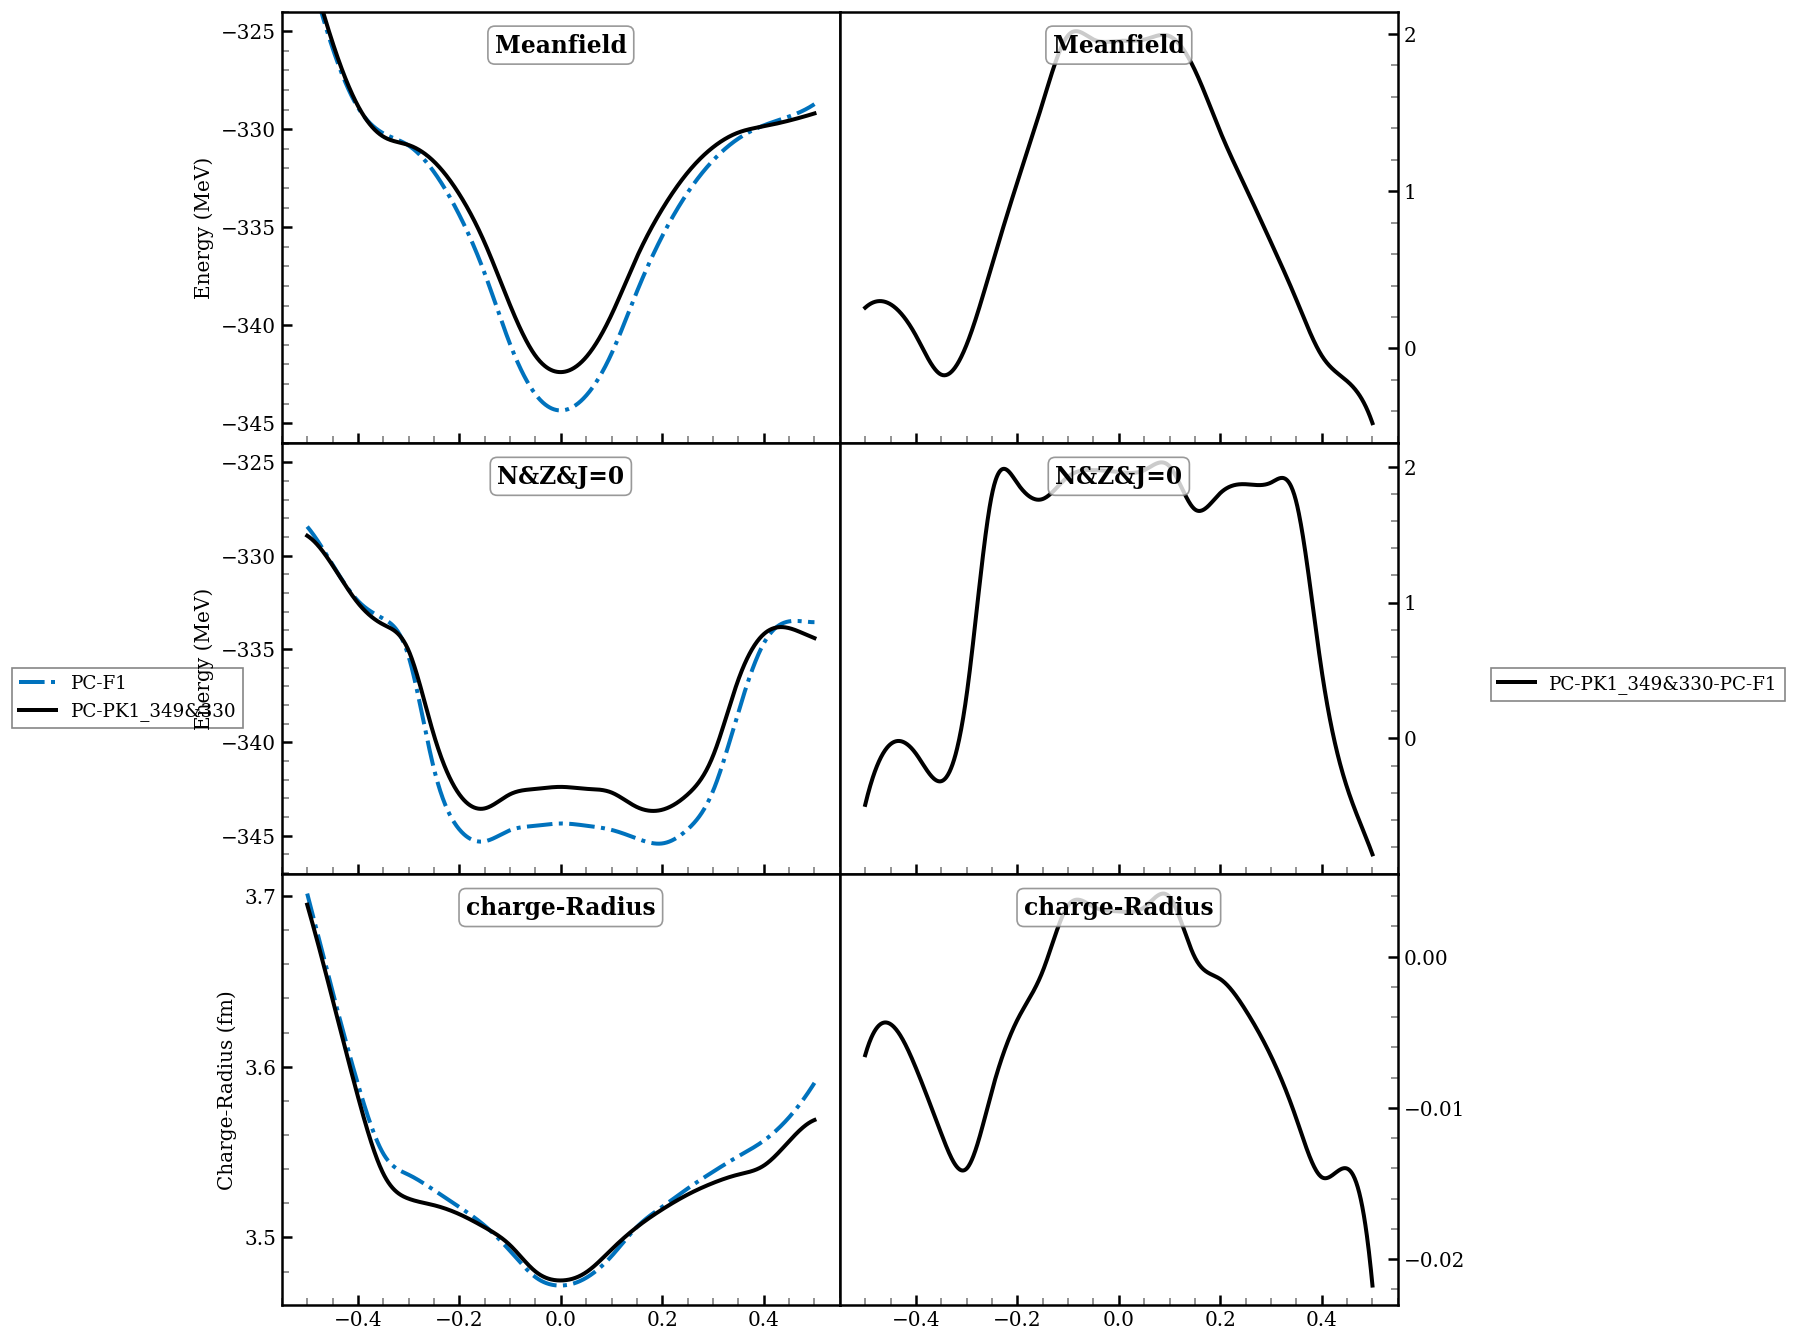

[OK] 新方式测试完成: test1/test_new.png

测试完成！请查看生成的图片文件。


In [71]:
labels=['PC-F1', 'PC-PK1_349&330']
# print(df[0].columns.tolist())
# 创建配置
config_A = SubplotConfig(
    df=interpolated_data(dfall[0], columss[0]),
    xname='beta2',
    y_columns=columss[0],
    labels=labels,
    ranges=(-345, -325),
    subtitle='Meanfield',
    ylabel='Energy (MeV)',
    high=[1,0], subhigh=[],
    linewidth=2.4,
)


config_B = SubplotConfig(
    df=interpolated_data(dfall[1], columss[1]),
    xname='beta2',
    y_columns=columss[1],
    labels=labels,
    ranges=(-346, -325),
    subtitle='N&Z&J=0',
    ylabel='Energy (MeV)',
    high=[1,0], subhigh=[],
    linewidth=2.4,
)

config_C = SubplotConfig(
    df=interpolated_data(dfall[2],columss[2]),
    xname='beta2',
    y_columns=columss[2],
    labels=labels,
    subtitle='charge-Radius',
    ylabel='Charge-Radius (fm)',
    high=[1,0], subhigh=[],
    linewidth=2.4,
)

templabels = ['PC-PK1_349&330-PC-F1', 'Nf=14-Nf=8', 'Nf=14-Nf=10', 'Nf=14-Nf=12']

# # 获取差值列名
# diff_cols_3 = dfs[3].columns.tolist()[2:]
# diff_cols_4 = dfs[4].columns.tolist()[2:]
# diff_cols_5 = dfs[5].columns.tolist()[2:]

config_D = SubplotConfig(
    df=interpolated_data(dfall[3], columss[3]),
    xname='beta2',
    y_columns=columss[3],
    labels=templabels,
    subtitle='Meanfield',
    is_right_placed_scale=True,
    high=[0], subhigh=[],
    linewidth=2.4,
)


config_E = SubplotConfig(
    df=interpolated_data(dfall[4], columss[4]),
    xname='beta2',
    y_columns=columss[4],
    labels=templabels,
    subtitle='N&Z&J=0',
    is_right_placed_scale=True,
    high=[0], subhigh=[],
    linewidth=2.4,
)

config_F = SubplotConfig(
    df=interpolated_data(dfall[5], columss[5]),
    xname='beta2',
    y_columns=columss[5],
    labels=templabels,
    subtitle='charge-Radius',
    is_right_placed_scale=True,
    high=[0], subhigh=[],
    linewidth=2.4,
)


# # === 使用示例1：旧方式（保持兼容）===
# # 注意：ylabel 参数已废弃，会触发 DeprecationWarning
# plot_legacy = Plot(
#     subplot_configs=[config_A, config_B, config_C, config_D, config_E, config_F],
#     num_rows=3,
#     num_cols=2,
#     sub_ax_locations_list=[
#         (0, 0), (1, 0),(2,0), (0, 1), (1, 1),(2,1)
#     ],
#     xlabel=r"$\beta_2$",
#     figsize=(12, 14),
#     legend_position=(0, 1),
# )
# fig1 = plot_legacy.plot()
# # plt.savefig('test1/test_legacy.png', dpi=150, bbox_inches='tight')
# plt.show()
# plt.close()
# print("[OK] 旧方式测试完成: test1/test_legacy.png")


# === 使用示例2：新方式 - 多图例 + 灵活坐标轴标签 ===
# 注意：ylabel 和 ylabel_locations 参数已废弃，会触发 DeprecationWarning
plot_new = Plot(
    subplot_configs=[config_A, config_B, config_C, config_D, config_E, config_F],
    num_rows=3,
    num_cols=2,
    sub_ax_locations_list=[
        (0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (2, 1)
    ],
    xlabel=r"$\beta_2$",
    figsize=(12, 14),
    # 新方式：定义多个图例组
    legend_groups=[
        {
            'subplot_indices': [0, 1, 2],  # 左列三个子图共享此图例
            'location': (0, 0),             # 图例放在左上角子图
            'fontsize': 11,
            'loc': 'upper left',
            'bbox_to_anchor': (-0.5, -0.50),  # 放在子图右上角外部
        },
        {
            'subplot_indices': [3, 4, 5],  # 右列三个子图共享此图例
            'location': (1, 1),             # 图例放在右上角子图
            'fontsize': 11,
            'loc': 'upper left',
            'bbox_to_anchor': (1.15, 0.5),  # 放在子图右上角外部
        }
    ],
    # 新方式：指定哪些位置显示坐标轴标签
    xlabel_locations=[(1, 0), (1, 1)],  # 底部两个子图显示xlabel
)
fig2 = plot_new.plot()
# plt.savefig('test1/test_new.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[OK] 新方式测试完成: test1/test_new.png")

print("\n测试完成！请查看生成的图片文件。")

## $\beta_2$
$\bra{0^+_1}\hat{Q^+}_2^+ \ket{2^+}=\bra{0^+_1}\hat{Q}_2^+ \ket{2^+}$

In [70]:
print(dfall)
print(columss)

[    beta2  beta3  Etot_PC-F1  Etot_PC-PK1_349&330
0   -0.50   0.01 -321.367005          -321.108015
1   -0.45   0.01 -325.861624          -325.580984
2   -0.40   0.01 -328.890653          -328.809108
3   -0.35   0.01 -330.211984          -330.378792
4   -0.30   0.01 -330.834978          -330.810364
5   -0.25   0.01 -332.186869          -331.654644
6   -0.20   0.01 -334.383085          -333.324909
7   -0.15   0.01 -337.364556          -335.801442
8   -0.10   0.01 -340.974104          -338.983329
9   -0.05   0.01 -343.527833          -341.563288
10   0.00   0.01 -344.350507          -342.394832
11   0.05   0.01 -343.590425          -341.626644
12   0.10   0.01 -341.448389          -339.462527
13   0.15   0.01 -338.286394          -336.517065
14   0.20   0.01 -335.450623          -334.072738
15   0.25   0.01 -333.236885          -332.213769
16   0.30   0.01 -331.597094          -330.923147
17   0.35   0.01 -330.479783          -330.170617
18   0.40   0.01 -329.807247          -329.853151

In [ ]:
from scipy.interpolate import interp1d
df_origin = pd.DataFrame()
delete_num = 0.1
# 将beta2=0的行对应的列energy_J2,4,6设为NAN
df_origin.loc[(df_origin['beta2'] >= -delete_num) & (df_origin['beta2'] <= delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
def interpolated_data(df_origin, y_columns,num_points=1000, kind='cubic'):


    # 获取数据
    df = df_origin.copy()
    x = df['beta2'].values.astype(float)

    # 创建统一的插值网格
    x_uniform = np.linspace(x.min(), x.max(), num_points)

    # 存储插值结果
    interpolated_data = {'beta2': x_uniform}

    # 处理每个列
    for col in y_columns:
        y_data = df[col].values.astype(float)
        
        # 创建非NaN掩码
        mask = ~np.isnan(y_data)
        
        # 找到连续非NaN段的边界
        diff = np.diff(mask.astype(int))
        split_indices = np.where(diff != 0)[0] + 1
        
        # 初始化插值结果数组
        y_interp = np.full(num_points, np.nan)
        
        # 处理每个分段
        start_indices = [0] + split_indices.tolist()
        end_indices = split_indices.tolist() + [len(y_data)]
        
        for s, e in zip(start_indices, end_indices):
            if s >= e:
                continue
                
            seg_x = x[s:e]
            seg_y = y_data[s:e]
            if np.all(np.isnan(seg_y)):
                continue
            
            # 单点段直接赋值
            if len(seg_x) == 1:
                idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                y_interp[idx] = seg_y[0]
                continue
                
            # 创建插值函数
            f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
            
            # 在当前分段范围内插值
            segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
            y_interp[segment_mask] = f(x_uniform[segment_mask])
        
        # 存储插值结果
        interpolated_data[col] = y_interp
    return interpolated_data


class Plot():
    def __init__(
        self,
        subplot_configs: List[SubplotConfig],
        num_rows: int = 3,
        num_cols: int = 2,
        sub_ax_locations_list: Optional[List[Tuple[int, int]]] = None,
        xlabel: str = r"$\beta_2$",
        ylabel: str = "Energy (MeV)",
        title: str = "Isotope chain",
        fontweight = 'normal',
        position: tuple[int, int] = (1,1),
        palettes: Any = None,
        figsize: Tuple[float, float] = (10, 8),
        closed_subplots: List[Tuple[int, int]] = [],
        default_config: Optional[SubplotConfig] = None
    ):
        self.subplot_configs = subplot_configs
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.sub_ax_locations_list = sub_ax_locations_list or [(0, 0) for _ in subplot_configs]
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.title = title
        self.fontweight = fontweight
        self.position = position
        self.palettes = palettes
        self.figsize = figsize
        # 关闭的子图
        self.closed_subplots = closed_subplots
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        self.subplots_adjust = (
            0,   # 垂直方向无间距
            0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        if len(self.subplot_configs) == 1:
            self.num_rows = 1
            self.num_cols = 1
            self.sub_ax_locations_list = [(0, 0)]
        self.default_config = default_config or SubplotConfig(pd.DataFrame())
        

    def _create_figure(self):
        # self.fig, self.axes = plt.subplots(
        #     self.num_rows, self.num_cols,
        #     figsize=self.figsize,
        #     dpi=self.dpi,
        #     squeeze=False,
        #     sharex='all' if self.share_x else 'none',
        #     sharey='all' if self.share_y else 'none'
        # )
        # 创建子图网格
        self.fig, self.axes = plt.subplots(self.num_rows, self.num_cols, figsize=self.figsize, dpi=120)
        
        for ax_closed in self.closed_subplots:
            self.axes[ax_closed[0], ax_closed[1]].axis('off')
        # 确保axes 是一个二维数组
        if self.num_rows == 1 and self.num_cols == 1:
            self.axes = np.array([[self.axes]])
        elif self.num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            self.axes = self.axes.reshape(1, -1)
        elif self.num_cols == 1:
            self.axes = self.axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in self.axes[:, 0]:
            ax.sharex(self.axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in self.axes[:, 1][:2]:
            ax.sharex(self.axes[0, 1])

        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=self.subplots_adjust[0],   # 垂直方向无间距
            wspace=self.subplots_adjust[1] # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        ) 
        self._assign_axes_to_subplot()
        self._apply_global_styles()
        self._assign_axes_to_subplot()

    def _apply_global_styles(self):
        pass

    def _assign_axes_to_subplot(self):
        pass

    def apply_style(self, plt):
        pass

    def plot(self):
        self._create_figure()
        for i, spc in enumerate(self.subplot_configs):
            ax = self.axes[self.sub_ax_locations_list[i]]
            subplot = Subplot(spc, ax, self.sub_ax_locations_list[i],  self.closed_subplots)
            # subplot.apply_style(plt)
            subplot.plot()
        ax = self.axes[self.position]
        ax.legend(
            fontsize=10.5,
            loc='center',
            # ncol=5,                    # 横向排列
            frameon=True,
            fancybox=True,
            shadow=False,
            bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
        )
        # 设置x轴标签
        for i in range(1, self.num_cols):
            ax = self.axes[self.num_rows, i]
            # 设置x坐标，标题
            ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

        fig.supylabel(self.ylabel, fontsize=20, fontweight='normal', x=0.04)
        


class Subplot:
    """
    绘制子图，读取子图配置，并绘制子图
    """
    def __init__(
        self,
        subplot_config: SubplotConfig(),
        ax: mpl_axes.Axes,
        sub_ax_location: Tuple[int, int],
        # palettes: Any,
        closed_subplots: List[Tuple[int, int]] = [],
        # default_config: Optional[SubplotConfig] = None
    ):
        self.spc = subplot_config
        self.ax = ax
        self.sub_ax_location = sub_ax_location
        # self.palettes = palettes
        self.closed_subplots = closed_subplots
        if self.spc.isrps:
            self.ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
        self.apply_tick_style()

    def apply_tick_style(self):
        if self.ax.get_visible():  # 仅处理可见子图
            # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）            
            self.ax.tick_params(**self.spc.axis_tick_params_major)
            self.ax.tick_params(**self.spc.axis_tick_params_minor)

    # def _plot_data(self):
        
    #     return x, y

    def _plot_point(self):
        """需要在子图中补充点时调用"""
        pass
    
    def plot(self): 
        self.ax.set_ylim(
            self.spc.ranges[0]-self.spc.ymargin_ratio*(self.spc.ranges[1]-self.spc.ranges[0]), 
            self.spc.ranges[1]+self.spc.ymargin_ratio*(self.spc.ranges[1]-self.spc.ranges[0])
            )
        self.ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
        self.ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
        self.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
        x = self.spc.df[self.spc.xname].values.astype(float)
        for i, y_col in enumerate(self.spc.y_columns):
            y = self.spc.df[y_col].values.astype(float)
            self.ax.plot(x, y, color=self.spc.colors[i % len(self.spc.colors)], linestyle=self.spc.linestyles[i % len(self.spc.linestyles)], linewidth=self.spc.linewidth, alpha=1, label=self.spc.labels[i])
        self.ax.annotate(
            self.spc.subtitle, 
            xy=(0.5, 0.95), xycoords='axes fraction',
            ha='center', va='top', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), 
            zorder=200)    
    


class SubplotConfig:
    """
    每个子图的完整配置。
    - 所有字段都可以外部显式设置。
    - 没设置的字段会继承 MainPlot 里的 default_config。
    """
    def __init__(
        self,
        df: pd.DataFrame,                          # 必须：本子图的数据
        xname: str = "x",
        y_columns: Optional[List[str]] = [],
        labels: Optional[List[str]] = [],
        ranges: Optional[Tuple[float, float]] = (None),  # (max_y, min_y) 与原来一致
        y_margin_ratio = 0.05,
        subtitle: str = "",                        # 子图左上角文字（优先使用）
        high: Optional[List[int]] = [0],
        subhigh: Optional[List[int]] = [1],
        plot_type: str = "line",                   # 支持 line / scatter / bar（目前只实现了 line）
        palettes: Optional[tjp] = tjp(),
        colorsname: str = 'nature5',
        linewidth: float = 2.4,
        linestyles: Optional[List[str]] = None,
        ax: mpl_axes.Axes = None,
        axis_tick_params_minor: Dict[str, Any] = {
            'axis': 'both',
            'which': 'minor',    # 只改辅刻度
            'direction': 'in',   # 辅刻度也朝内
            'length': 4,        # 辅刻度线更短（默认比主刻度短）
            'width': 1,          # 辅刻度线更细
            'colors': 'gray'     # 辅刻度线颜色（可选，弱化视觉）
        },
        axis_tick_params_major: Dict[str, Any] = {
            'axis': 'both',
            'direction': 'in'
        },
        is_right_placed_scale: bool = False,
        nan_columns: Optional[List[str]] = None,   # 新增：要置 NaN 的列（默认 J2,J4,J6）
        gcm_energy: Optional[float] = None,        # 新增：用于红色短线
        beta2_expectation: float = 0.0,            # 新增：红色短线 x 位置
        nuc: str = "",                             # 新增：如果 subtitle 为空，可用来生成 LaTeX
        **kwargs: Any
    ):
        self.df = df
        self.xname = xname
        self.y_columns = y_columns
        self.labels = labels
        self.ranges = ranges
        self.y_margin_ratio = y_margin_ratio
        self.subtitle = subtitle
        self.highlight_indices = high
        self.sub_highlight_indices = subhigh
        self.plot_type = plot_type
        self.palettes = palettes
        self.colorsname = colorsname
        self.linewidth = linewidth
        # self.colors = colors
        # self.linestyles = linestyles
        # self.nan_columns = nan_columns
        # self.gcm_energy = gcm_energy
        # self.beta2_expectation = beta2_expectation
        # self.nuc = nuc
        self.extra = kwargs
        # self.ax = ax
        self.axis_tick_params_major = axis_tick_params_major
        self.axis_tick_params_minor = axis_tick_params_minor
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        self.isrps = is_right_placed_scale    
        self._range_y()
        self._assign_color()

    def _assign_color(self):
        self.colors, self.linestyles = self.palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=self.highlight_indices,
                                                    sub_emphasize_indices=self.sub_highlight_indices   # 可以为空
                                                )
        
    def _range_y(self):
        """
        返回 y 轴范围。
        """
        if self.ranges:
            return self.ranges
        else:
            self.ranges = (self.df[self.y_columns].min().min(), self.df[self.y_columns].max().max())

class Plot():
    def __init__(
            self, cores, palettes, MainPlotConfig: MainPlotConfig, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.cores = cores
        self.mpc = MainPlotConfig
        self.df_origin = self.cores[1].df
        self.y_columns = y_columns
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        self.title     = title
        
        # 刻度
        self.ticks = ticks
        self.ranges = ranges


    
    def plot_package(self, text, figsize):

        interpolated_data = interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))



        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), 
                               sub_ax_locations_list=[(0, 0), 
                                                    (1, 0), (1, 1),
                                                    (2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 访问MainPlotConfig
        
        # 创建子图网格
        fig, axes = plt.subplots(self.mpc.num_rows, self.mpc.num_cols, figsize=self.mpc.figsize, dpi=120)
        axes[0, 1].axis('off')
        if self.mpc.closed_subplots: 
            for i in self.mpc.closed_subplots:
                axes[i[0], i[1]].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if self.mpc.num_rows == 1 and self.mpc.num_cols == 1:
            axes = np.array([[axes]])
        elif self.mpc.num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif self.mpc.num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=self.mpc.subplots_adjust[0],   # 垂直方向无间距
            wspace=self.mpc.subplots_adjust[1] # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core in enumerate(self.cores):
            
            # print("运行到我了")
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = core.df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = core.gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))

            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0]


            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=1,
                        label=self.labels[i]
                        )
            # print(self.cores)
            # print(idx, self.cores[idx].NUC)
            ax.annotate(f"$^{{{self.cores[idx].NUC[0:2]}}}${self.cores[idx].NUC[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = beta2_expectation[idx]          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.02   # 短线左右各延伸多少（单位是 beta2）


            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=1.5,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


KeyError: 'beta2'

In [ ]:
figsize=(8 , 4)

In [ ]:
df_exp = pd.read_csv('/home/xizhang/datasets/charge_radii.csv')
df_exp_Ca = df_exp[(df_exp['symbol']=='Ca') & (df_exp['n']%2==0) & (df_exp['n']<30)]
# df_exp_Ca = df_exp_Ca[df_exp_Ca['a', 'radius_val']]
# 选出'a', 'radius_val'列
df_exp_Ca = df_exp_Ca[['a', 'radius_val']].rename(columns={'a':'A', 'radius_val':'Exp'})
print(df_exp_Ca)

     A     Exp
89  40  3.4776
91  42  3.5081
93  44  3.5179
95  46  3.4953
97  48  3.4771


    A       GCM  Meanfield       N&J     Exp
0  40  3.488688   3.362253  3.490147  3.4776
1  42  3.496859   3.406800  3.493260  3.5081
2  44  3.505518   3.450077  3.494038  3.5179
3  46  3.549804   3.491819  3.499194  3.4953
4  48  3.513984   3.528895  3.515443  3.4771
[3.48868775 3.49685911 3.50551803 3.54980418 3.51398353]
[3.49014685 3.49325969 3.49403792 3.49919398 3.51544322]
[3.4776 3.5081 3.5179 3.4953 3.4771]


(3.47, 3.555)

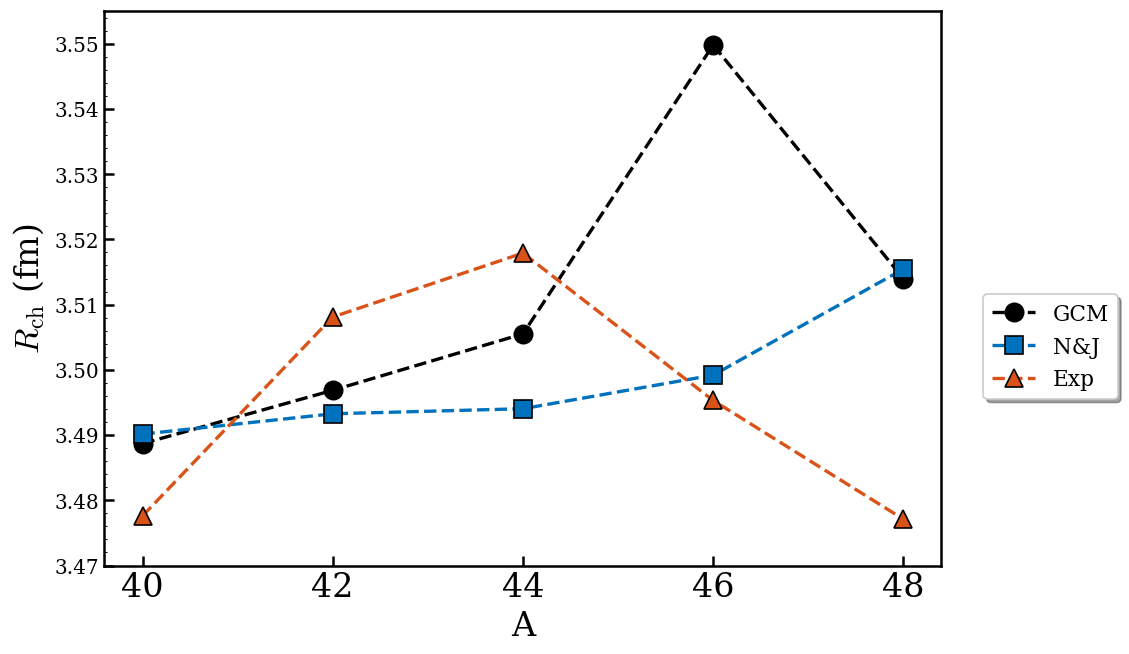

In [ ]:
import pandas as pd
import numpy as np
df_create = pd.DataFrame(
    [[40,np.sqrt(3.3935**2+0.77-0.1149) ],
     [42, np.sqrt(3.4019**2+0.77-0.1149)], 
     [44,np.sqrt(3.4108**2+0.77-0.1149)], 
    [46, np.sqrt(3.4563**2+0.77-0.1149)], 
    [48,np.sqrt(3.4195**2+0.77-0.1149)]],
    columns=['A', 'GCM'])
df_create0 = pd.DataFrame(
    [[40,np.sqrt(3.360007**2-0.64+0.77-0.1149) ],
     [42, np.sqrt(3.404583**2-0.64+0.77-0.1149)], 
     [44,np.sqrt(3.447888 **2-0.64+0.77-0.1149)], 
    [46, np.sqrt(3.489656**2-0.64+0.77-0.1149)], 
    [48,np.sqrt(3.526755**2-0.64+0.77-0.1149)]],
    columns=['A', 'Meanfield'])
3.3963, 3.3950, 3.3982, 3.3990, 3.4043, 3.4210 # type: ignore
df_create1 = pd.DataFrame([
        # [40,np.sqrt(3.3963**2+0.77-0.1149) ],
    [40,np.sqrt(3.3950**2+0.77-0.1149) ],
    [42, np.sqrt(3.3982**2+0.77-0.1149)], 
    [44,np.sqrt(3.3990**2+0.77-0.1149)], 
    [46, np.sqrt(3.4043**2+0.77-0.1149)],
    [48,np.sqrt(3.4210**2+0.77-0.1149)]],
    columns=['A', 'N&J'])
df_create2 = pd.DataFrame(
    [[40, (3.47727) ],
     [42, (3.50635)], 
     [44, (3.51854)], 
    [46, (3.49515)], 
    [48, (3.47727)]],
    columns=['A', 'prl-2025'])
[3.47727,
3.50635,
3.51854,
3.49515,
3.47727] # type: ignore
# 合并为一个 df
df11 = (
    df_create
    .merge(df_create0, on='A', how='outer')
    .merge(df_create1, on='A', how='outer')
    # .merge(df_create2, on='A', how='outer')
    .merge(df_exp_Ca, on='A', how='outer')
)
print(df11)

x_name = 'A'

df_origin = df11.copy()

x = df_origin[x_name].values.astype(float)
xlabel = 'A'
ylabel = f'$R_\\text{{ch}}$ (fm)'

y_columns=[  'GCM', 'N&J', 'Exp']
labels = y_columns

text = None

# 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
figsize = (9, 6)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

# 假设你的数据框是 merged_nodio_plus
# merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

# 颜色 / 线型
# 1. 决定总共几条线、哪些要重点突出
total_lines = len(y_columns)
highlight = [0, 1, 2]          # 第0条和第2条要最显眼（从0开始数）
subhighlight = []

# 2. 自动获取颜色和线型（默认用蓝色系）
colors, linestyles = palettes.get_all_colors_linestyles(total_lines, highlight,subhighlight)
markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*']

fontsize = 20
fontweight = "normal"

plt.figure(figsize=figsize, dpi=120)
# 遍历每条曲线
for i, y_col in enumerate(y_columns):
        # 获取当前列的数值数据（注意转换为 float 避免类型错误）
        y_data = df_origin[y_col].astype(float).to_numpy()
        print(y_data)
        # print(type(merged))
        # # 绘制平滑曲线（如果需要插值）
        # plt.plot(x, y_data,
        #         color=colors[i % len(colors)],
        #         linestyle=linestyles[i % len(linestyles)],
        #         linewidth=2.4,
        #         alpha=0.95,
        #         label=labels[i])
        # 刻度朝内
        plt.tick_params(axis='both', which='both', direction='in')
        
        # 设置辅刻度
        plt.minorticks_on()
        plt.tick_params(axis='x', which='minor', bottom=False, top=False)
        plt.plot(
                x, y_data,
                # 1. 颜色：保持原逻辑（循环取色）
                color=colors[i % len(colors)],
                # 2. 线型：设为无（不画线条）
                linestyle='--',  
                # 3. 标记：指定点的形状（示例用圆形，可替换为其他符号）
                marker=markers[i % len(markers)],         
                # 4. 标记大小：建议2-10（根据数据密度调整）
                markersize=11,        
                # 5. 标记填充色：可选与线条同色（或自定义）
                markerfacecolor=colors[i % len(colors)],  
                # 6. 标记边缘色：可选黑色（增强对比）
                markeredgecolor='black',  
                # 7. 边缘宽度：让点更清晰（可选）
                markeredgewidth=1,  
                # 8. 透明度：保持原逻辑（若点重叠时用）
                alpha=1,          
                # 9. 标签：保持原逻辑（用于图例）
                label=labels[i]       
            )
        # 添加虚线

        # plt.scatter(x, y_data, s=80, marker=markers[i],zorder=20, label=labels[i], color=colors[i % len(colors)], alpha=1) 
        plt.legend(fontsize=13, loc=(1.05, 0.3), frameon=True, shadow=True, fancybox=True) # 参数: frameon=True, 用于控制边框, shadow=True, 用于控制阴影, fancybox=True, 用于控制边框的形状
        
        # print(type(df_origin))
plt.xticks(np.arange(40, 50, 2), fontsize=fontsize, fontweight=fontweight)

plt.ylabel(ylabel, fontsize=fontsize, fontweight=fontweight)
plt.xlabel(xlabel, fontsize=fontsize, fontweight=fontweight)
# plt.title(title, fontsize=fontsize, fontweight=fontweight, pad=15)
plt.ylim(3.47, 3.555)



# plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

# if text:
#     plt.annotate(text, 
#         xy=(0.5, 0.95), xycoords='axes fraction',
#         ha='center', va='top', fontsize=14, fontweight='bold',
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

# # 黑色强调实验值（如果你有实验点，可在这里额外画）
# # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
# # print(colors)
# # plt.tight_layout()